# Exercise 4 — Global vs. local explanations

**PCS956 • Module C • Week 1**

## Research question

**How does understanding broad model behaviour differ from explaining one individual prediction?**

We train one Random Forest and keep it fixed throughout the notebook.

SHAP is used only to demonstrate the **scope** distinction:

- local SHAP values describe individual model outputs;
- aggregating local attributions across observations provides global summaries.

Detailed SHAP assumptions and variants are left for the next lecture.


## Dataset: Titanic

We use the same Titanic passenger dataset throughout all four Week 1 practical notebooks so that the **data remain fixed while the explanation question changes**.

Each row represents one passenger. The target is:

- `survived = 1` — the passenger was recorded as surviving;
- `survived = 0` — the passenger was recorded as not surviving.

We use these predictors:

| Feature | Meaning |
|---|---|
| `pclass` | Passenger class: 1st, 2nd, or 3rd |
| `sex` | Recorded sex |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation |

The seaborn version of the dataset contains missing values, including missing `age` and `embarked` values. Preprocessing is therefore fitted **only on the training data** and then applied to the test data.

### Scientific caution

This is historical observational data. These notebooks investigate **model behaviour**. Feature importance, decision rules, and SHAP attributions should not be interpreted as causal effects on survival.


## 1. Setup and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

RANDOM_STATE = 42

titanic = sns.load_dataset("titanic")

FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="if_binary"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:", list(feature_names))

from sklearn.ensemble import RandomForestClassifier


Training observations: 712
Test observations: 179
Transformed features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 2. Train one fixed predictive model


In [2]:
forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest.fit(X_train_df, y_train)

test_pred = forest.predict(X_test_df)

print("Test accuracy:",
      round(accuracy_score(y_test, test_pred), 3))
print("Test balanced accuracy:",
      round(balanced_accuracy_score(y_test, test_pred), 3))


Test accuracy: 0.81
Test balanced accuracy: 0.791


### Discuss the predictive result

These metrics describe predictive performance on the test set.

They do not yet tell us which features receive large attributions globally or why the model gives a particular passenger a specific output.


## 3. Compute class-specific SHAP attributions

We focus on class `1` (`survived`).

SHAP values are local attributions. A global SHAP summary is obtained by aggregating those local values across observations.


In [3]:
# Uncomment if SHAP is not installed:
# !pip install shap

import shap

explainer = shap.TreeExplainer(forest)
shap_values = explainer(X_test_df)

if shap_values.values.ndim == 3:
    survived_values = shap_values.values[:, :, 1]
    survived_base_values = shap_values.base_values[:, 1]
else:
    survived_values = shap_values.values
    survived_base_values = shap_values.base_values

survived_explanation = shap.Explanation(
    values=survived_values,
    base_values=survived_base_values,
    data=X_test_df.values,
    feature_names=list(feature_names)
)


## 4. Global explanation: mean absolute SHAP attribution

A common global summary ranks features by the mean absolute magnitude of their local attributions across the evaluated observations.


,feature,mean_absolute_SHAP
5,sex_male,0.208511
0,pclass,0.084367
4,fare,0.072280
1,age,0.053839
2,sibsp,0.025644
8,embarked_S,0.020160
6,embarked_C,0.014433
3,parch,0.012419
7,embarked_Q,0.007784


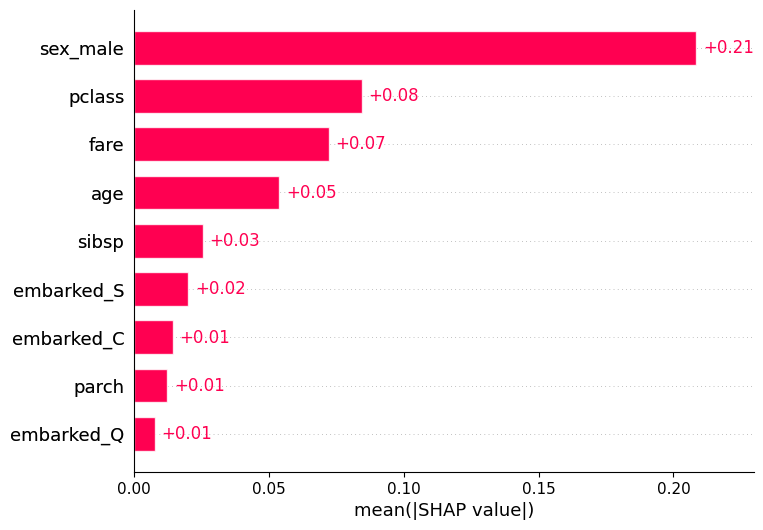

In [4]:
mean_abs_shap = np.abs(survived_values).mean(axis=0)

global_table = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_absolute_SHAP": mean_abs_shap
    })
    .sort_values("mean_absolute_SHAP", ascending=False)
)

display(global_table)

shap.plots.bar(
    survived_explanation,
    max_display=12
)


### Discuss the global result

The ranking answers a specific question:

> Which transformed features have larger **absolute SHAP attributions on average across these test observations**?

The mean absolute value discards direction. It does not tell us whether a feature always pushes toward survival or always pushes away from it.

It also does not imply causality.


### Optional global distribution view

A beeswarm plot retains more information than a bar ranking because it shows the distribution and sign of local attributions across observations.


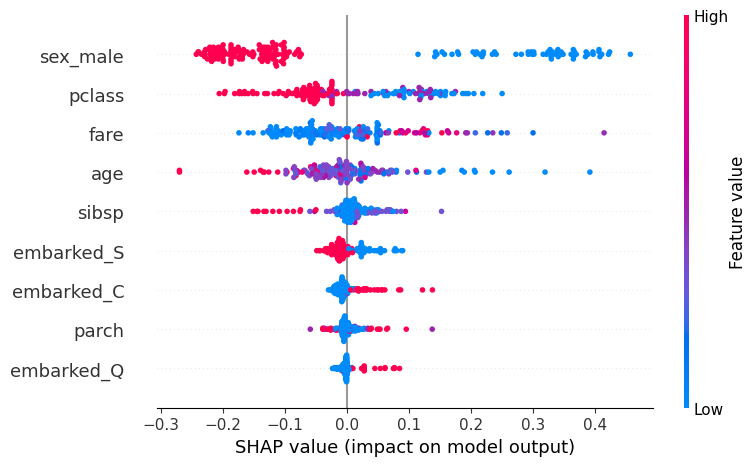

In [5]:
shap.plots.beeswarm(
    survived_explanation,
    max_display=12
)


### Discuss the beeswarm

Compare the beeswarm with the mean-absolute ranking:

- Which features have broad attribution distributions?
- Do some features push the model output in both directions across different passengers?
- Why can this information disappear in a single global importance number?


## 5. Local explanation for one passenger


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.15,S


Predicted survival probability: 0.1633


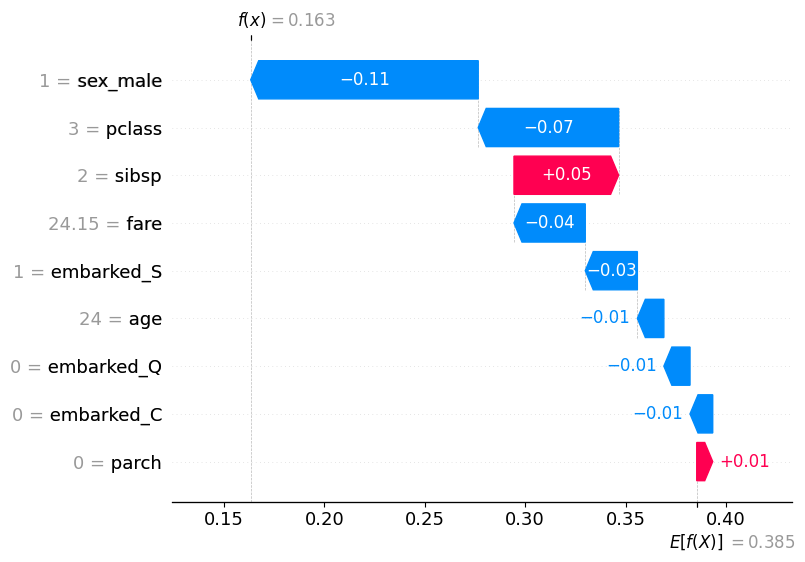

In [6]:
passenger_a = 0

display(X_test_raw.iloc[[passenger_a]])

prob_a = forest.predict_proba(
    X_test_df.iloc[[passenger_a]]
)[0, 1]

print("Predicted survival probability:",
      round(prob_a, 4))

shap.plots.waterfall(
    survived_explanation[passenger_a],
    max_display=12
)


### Discuss the local result

This waterfall plot concerns **one model output**.

Identify the largest positive and negative attributions for this passenger and compare them with the global ranking.

A globally important feature need not dominate every individual prediction.


## 6. Compare two contrasting passengers

We now select the test passenger with the lowest predicted survival probability and the passenger with the highest predicted survival probability.


In [7]:
survival_probabilities = forest.predict_proba(X_test_df)[:, 1]

passenger_low = int(np.argmin(survival_probabilities))
passenger_high = int(np.argmax(survival_probabilities))

comparison = pd.DataFrame({
    "test_position": [passenger_low, passenger_high],
    "predicted_survival_probability": [
        survival_probabilities[passenger_low],
        survival_probabilities[passenger_high]
    ]
})

display(comparison)

print("\nLow-probability passenger:")
display(X_test_raw.iloc[[passenger_low]])

print("High-probability passenger:")
display(X_test_raw.iloc[[passenger_high]])


,test_position,predicted_survival_probability
0,17,0.0
1,25,1.0



Low-probability passenger:


,pclass,sex,age,sibsp,parch,fare,embarked
511,3,male,NaN,0,0,8.05,S


High-probability passenger:


,pclass,sex,age,sibsp,parch,fare,embarked
369,1,female,24.0,0,0,69.3,C


Low predicted-survival passenger


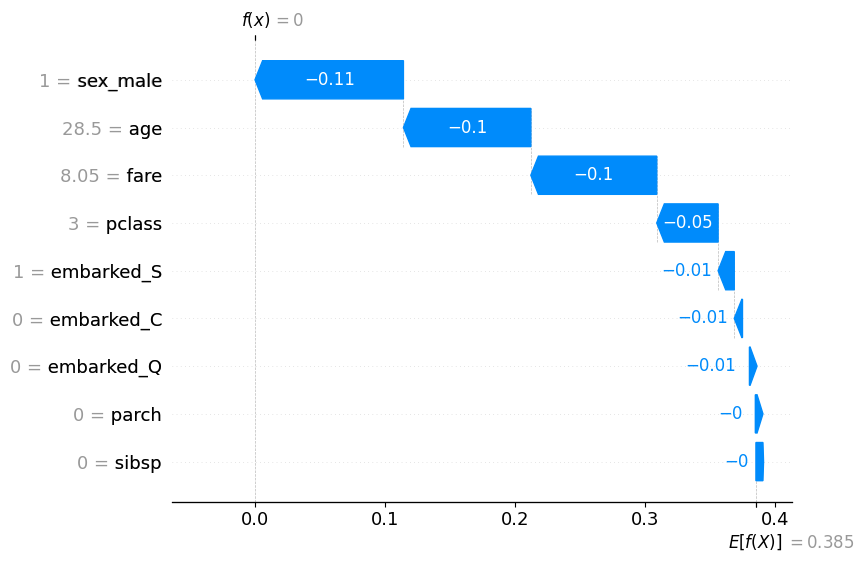

In [8]:
print("Low predicted-survival passenger")
shap.plots.waterfall(
    survived_explanation[passenger_low],
    max_display=10
)


High predicted-survival passenger


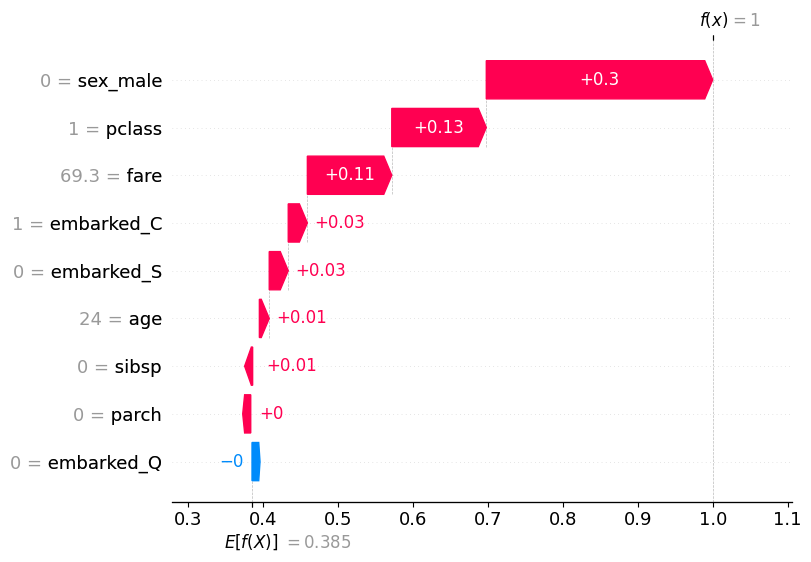

In [9]:
print("High predicted-survival passenger")
shap.plots.waterfall(
    survived_explanation[passenger_high],
    max_display=10
)


### Discuss the contrast

Compare the two local explanations.

Ask:

- Are the same features important for both passengers?
- Do the signs of the attributions differ?
- Can two very different local attribution patterns coexist within the same global model?

This is the central reason global and local explanations are complementary rather than interchangeable.


## 7. Quantify local variability for the top global feature


In [10]:
top_feature = global_table.iloc[0]["feature"]
top_feature_index = list(feature_names).index(top_feature)

feature_attributions = survived_values[:, top_feature_index]

summary = pd.Series(feature_attributions).describe()
print("Top global feature:", top_feature)
display(summary.to_frame("SHAP attribution"))

print(
    "Attribution for low-probability passenger:",
    round(feature_attributions[passenger_low], 6)
)
print(
    "Attribution for high-probability passenger:",
    round(feature_attributions[passenger_high], 6)
)


Top global feature: sex_male


,SHAP attribution
count,179.000000
mean,-0.002831
std,0.228498
min,-0.242683
25%,-0.185347
50%,-0.119326
75%,0.227680
max,0.457557


Attribution for low-probability passenger: -0.11419
Attribution for high-probability passenger: 0.302061


### Discuss the variability

Even the top globally ranked feature can have different attribution magnitudes—and potentially different signs—across individual observations.

A global summary compresses heterogeneous local behaviours.


## Student task

Select two test passengers with the **same predicted class** and compare their local explanations.

1. Identify the largest positive and negative SHAP attributions for each passenger.
2. Compare these local explanations with the global mean absolute SHAP ranking.
3. Explain whether the same globally important features dominate both individual predictions.
4. Summarise in 3–4 sentences why global and local explanations answer different questions.

Interpret the attributions as explanations of the fitted model output, not as causal effects.


## 8. Critical discussion

1. What information is lost when local attributions are reduced to mean absolute values?
2. Why should one passenger's waterfall plot not be generalized to the whole model?
3. Can two passengers receive similar predicted probabilities for different local reasons?
4. Can a globally important feature have a small attribution for one passenger?
5. Why is a SHAP attribution still a statement about model output rather than a causal effect?
6. Which scope would be more useful for debugging the model globally? Which for reviewing one prediction?


## 9. Takeaway

**Global explanations** summarize broader patterns across many observations.

**Local explanations** focus on one prediction or a small region of the model's behaviour.

A global SHAP summary is built from local attributions; aggregation is useful, but it inevitably discards some local information.
